# Digit Recognition for Optical Sudoku Solver

This notebook trains a Support Vector Machine (SVM) classifier to recognize printed digits (1–9) from extracted Sudoku cell images.

**Pipeline:**
1. Download and prepare the Chars74K `EnglishFnt` dataset
2. Preprocess images and extract HOG features
3. Train and evaluate an SVM classifier
4. Export the trained model to `models/digit_model.pkl`

## 1. Dataset Setup

The [Chars74K](http://www.ee.surrey.ac.uk/CVSSP/demos/chars74k/) dataset contains computer-rendered characters across 1,016 fonts. We use the `EnglishFnt` subset, which covers digits and letters in clean typeset form — well-matched to printed Sudoku puzzles.

The cell below downloads and extracts the dataset into `data/` automatically if it is not already present.

In [30]:
import urllib.request
import tarfile
import os

DATASET_URL = "http://www.ee.surrey.ac.uk/CVSSP/demos/chars74k/EnglishFnt.tgz"
DATA_DIR = "data"
ARCHIVE_PATH = os.path.join(DATA_DIR, "EnglishFnt.tgz")
EXTRACT_PATH = os.path.join(DATA_DIR, "English", "Fnt")

def download_progress(block_num, block_size, total_size):
    downloaded = block_num * block_size
    percent = min(downloaded / total_size * 100, 100)
    print(f"\rDownloading... {percent:.1f}%", end="", flush=True)

if not os.path.exists(EXTRACT_PATH):
    os.makedirs(DATA_DIR, exist_ok=True)
    print("Downloading Chars74K EnglishFnt dataset...")
    urllib.request.urlretrieve(DATASET_URL, ARCHIVE_PATH, reporthook=download_progress)
    print("\nExtracting...")
    with tarfile.open(ARCHIVE_PATH, "r:gz") as tar:
        tar.extractall(DATA_DIR)
    os.remove(ARCHIVE_PATH)
    print(f"Dataset ready at: {EXTRACT_PATH}")
else:
    print(f"Dataset already present at: {EXTRACT_PATH}")

Dataset already present at: data/English/Fnt


## 2. Data Loading and Preprocessing

In the Chars74K `EnglishFnt` dataset, class folders are numbered sequentially across all 62 character classes (10 digits + 26 uppercase + 26 lowercase):
- `Sample001` → digit `0` (unused — Sudoku has no zeros)
- `Sample002` → digit `1`
- `Sample003` → digit `2`
- ...
- `Sample010` → digit `9`

Each folder contains 1,016 images — one rendering per font.

We resize every image to **45×45 pixels** to match the Sudoku cell size produced by `Image_Processing.ipynb`.

In [31]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import joblib

In [32]:
CELL_SIZE = 40  # must match the cell size produced by Image_Processing.ipynb

# Chars74K Sample folder index for digits 1-9
# Sample001 = '0', Sample002 = '1', ..., Sample010 = '9'
DIGIT_SAMPLES = {
    digit: f"Sample{digit + 1:03d}"
    for digit in range(1, 10)
}

images = []
labels = []

for digit, sample_folder in DIGIT_SAMPLES.items():
    folder_path = os.path.join(EXTRACT_PATH, sample_folder)
    filenames = sorted(os.listdir(folder_path))
    for fname in filenames:
        if not fname.endswith(".png"):
            continue
        img_path = os.path.join(folder_path, fname)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (CELL_SIZE, CELL_SIZE))
        images.append(img)
        labels.append(digit)

images = np.array(images)  # shape: (N, 40, 40)
labels = np.array(labels)  # shape: (N,)

print(f"Loaded {len(images)} images across digits 1–9")
print(f"Images per digit: {len(images) // 9}")
print(f"Image shape: {images[0].shape}")

Loaded 9144 images across digits 1–9
Images per digit: 1016
Image shape: (40, 40)


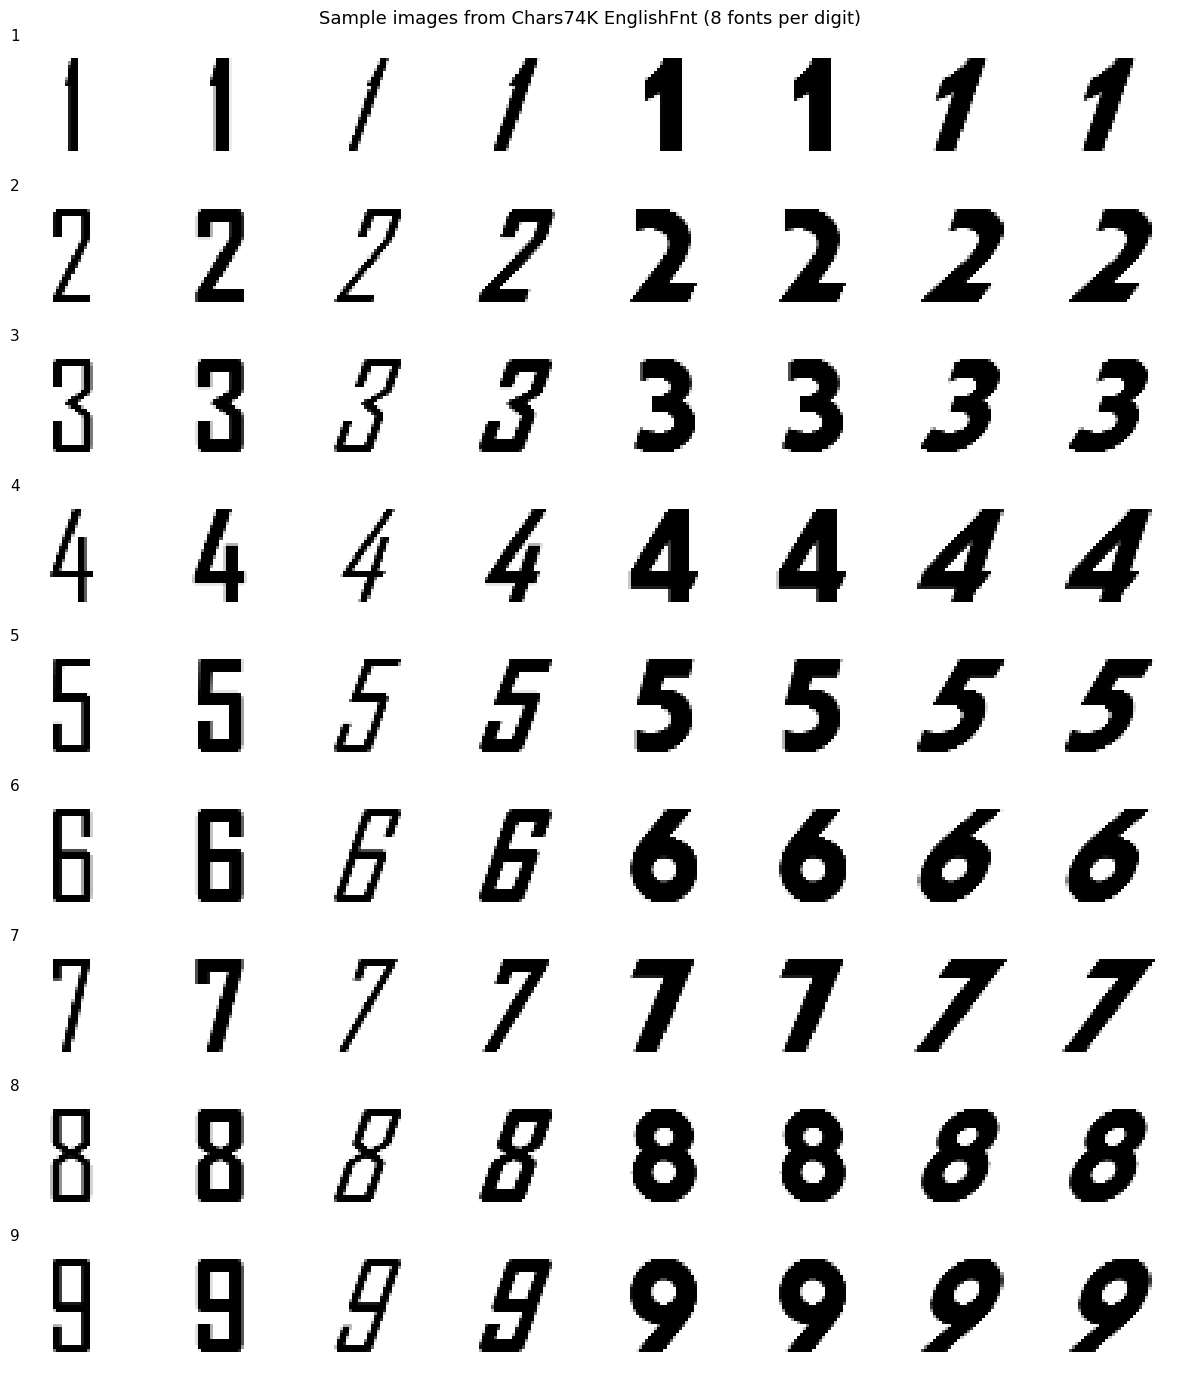

In [33]:
fig, axes = plt.subplots(9, 8, figsize=(12, 14))
fig.suptitle("Sample images from Chars74K EnglishFnt (8 fonts per digit)", fontsize=13)

for row, digit in enumerate(range(1, 10)):
    digit_indices = np.where(labels == digit)[0]
    sample_indices = digit_indices[:8]
    for col, idx in enumerate(sample_indices):
        axes[row, col].imshow(images[idx], cmap="gray")
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_title(str(digit), fontsize=11, loc="left", pad=2)

plt.tight_layout()
plt.show()

## 3. HOG Feature Extraction

We use **Histogram of Oriented Gradients (HOG)** to convert each 40×40 pixel image into a compact feature vector that captures the shape and edge structure of each digit — making the classifier robust to minor font variations.

**Parameters:**
- `pixels_per_cell=(8, 8)` — divides the 40×40 image into a 5×5 grid of cells (40/8 = 5)
- `cells_per_block=(2, 2)` — local contrast normalization over 2×2 cell blocks
- `orientations=9` — 9 gradient direction bins (0°–180°)

This produces a **576-dimensional feature vector** per image.

In [34]:
HOG_PARAMS = dict(
    orientations=9,
    pixels_per_cell=(8, 8),   # 40/8 = 5 → clean 5x5 grid of cells
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
)

def extract_hog_features(imgs):
    features = []
    for img in imgs:
        # Normalize pixel values to [0, 1] before HOG
        img_norm = img.astype(np.float32) / 255.0
        feat = hog(img_norm, **HOG_PARAMS)
        features.append(feat)
    return np.array(features)

X = extract_hog_features(images)
y = labels

print(f"Feature matrix shape: {X.shape}")
print(f"Feature vector size per image: {X.shape[1]}")

Feature matrix shape: (9144, 576)
Feature vector size per image: 576


### HOG Visualization

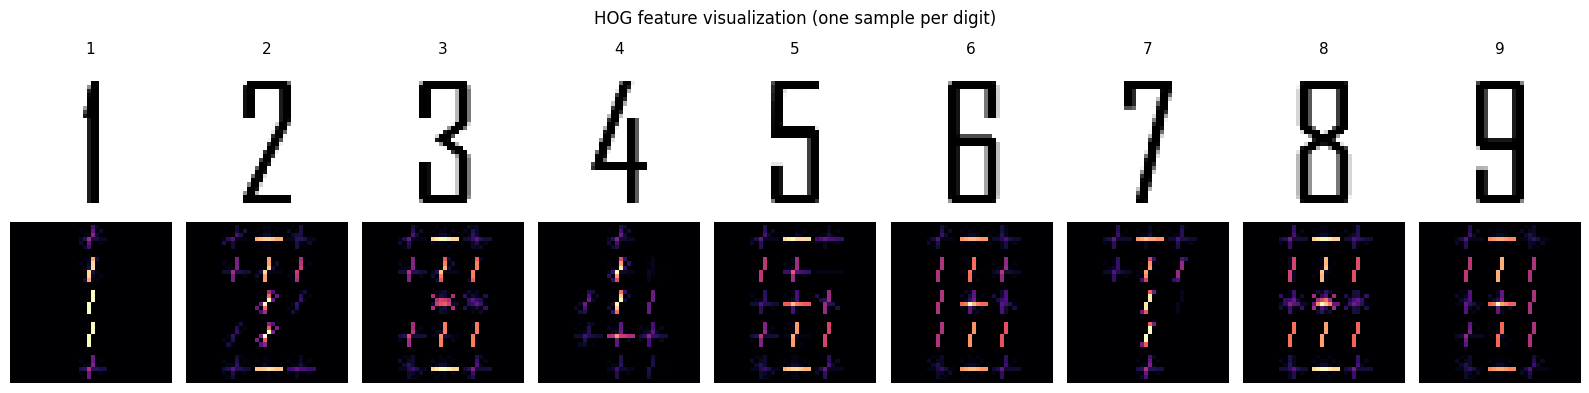

In [35]:
from skimage.feature import hog as skimage_hog

fig, axes = plt.subplots(2, 9, figsize=(16, 4))
fig.suptitle("HOG feature visualization (one sample per digit)", fontsize=12)

for col, digit in enumerate(range(1, 10)):
    idx = np.where(labels == digit)[0][0]
    img_norm = images[idx].astype(np.float32) / 255.0
    _, hog_image = skimage_hog(img_norm, **HOG_PARAMS, visualize=True)

    axes[0, col].imshow(images[idx], cmap="gray")
    axes[0, col].set_title(str(digit), fontsize=11)
    axes[0, col].axis("off")

    axes[1, col].imshow(hog_image, cmap="magma")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=10)
axes[1, 0].set_ylabel("HOG", fontsize=10)
plt.tight_layout()
plt.show()

## 4. Train / Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

# Class distribution check
unique, counts = np.unique(y_train, return_counts=True)
print("\nTraining samples per digit:")
for d, c in zip(unique, counts):
    print(f"  Digit {d}: {c}")

Training samples : 7315
Test samples     : 1829

Training samples per digit:
  Digit 1: 813
  Digit 2: 813
  Digit 3: 813
  Digit 4: 812
  Digit 5: 813
  Digit 6: 813
  Digit 7: 812
  Digit 8: 813
  Digit 9: 813


## 5. SVM Training

We train a Support Vector Machine with an **RBF (radial basis function) kernel**. RBF is well-suited for HOG features because it can model the non-linear boundaries between digit classes.

**Hyperparameters:**
- `C=10` — regularization strength; penalizes misclassifications (higher = tighter fit)
- `gamma='scale'` — sets the RBF kernel width automatically based on feature variance

In [37]:
svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42)
svm.fit(X_train, y_train)
print("SVM training complete.")

SVM training complete.


### Cross-Validation

5-fold cross-validation on the training set gives an unbiased estimate of generalization accuracy before we touch the test set.

In [38]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(svm, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
print(f"Cross-validation accuracy (5-fold): {cv_scores}")
print(f"Mean: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

Cross-validation accuracy (5-fold): [0.99658237 0.99384826 0.99043062 0.99179768 0.99111415]
Mean: 0.9928  |  Std: 0.0022


### Test Set Evaluation

In [39]:
y_pred = svm.predict(X_test)

print(classification_report(y_test, y_pred, target_names=[str(d) for d in range(1, 10)]))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00       203
           2       1.00      0.99      1.00       203
           3       1.00      0.99      0.99       203
           4       0.98      1.00      0.99       204
           5       0.99      1.00      0.99       203
           6       1.00      1.00      1.00       203
           7       1.00      1.00      1.00       204
           8       1.00      1.00      1.00       203
           9       1.00      1.00      1.00       203

    accuracy                           1.00      1829
   macro avg       1.00      1.00      1.00      1829
weighted avg       1.00      1.00      1.00      1829



### Confusion Matrix

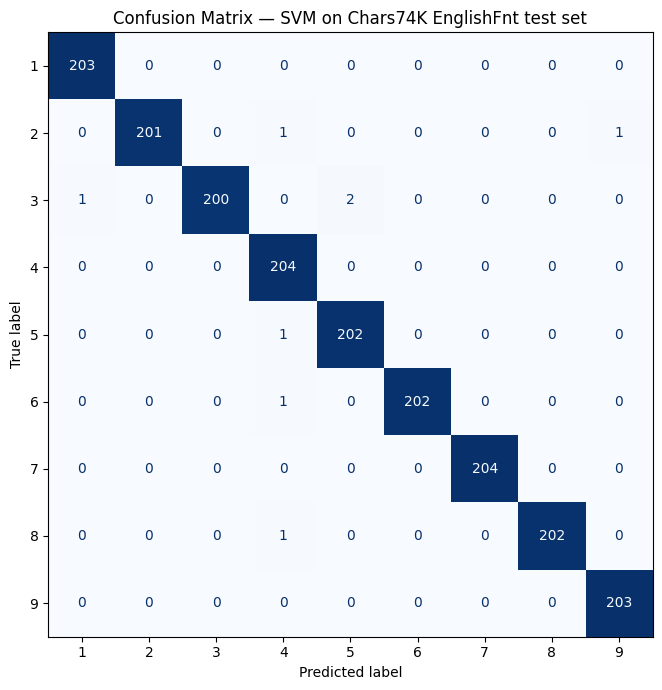

In [40]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — SVM on Chars74K EnglishFnt test set")
plt.tight_layout()
plt.show()

## 6. Export Model

Save the trained model to `models/digit_model.pkl` for use in `Image_Processing.ipynb`.

In [41]:
os.makedirs("models", exist_ok=True)
joblib.dump(svm, "models/digit_model.pkl")
print("Model saved to models/digit_model.pkl")

Model saved to models/digit_model.pkl
